<Figure size 1300x650 with 0 Axes>

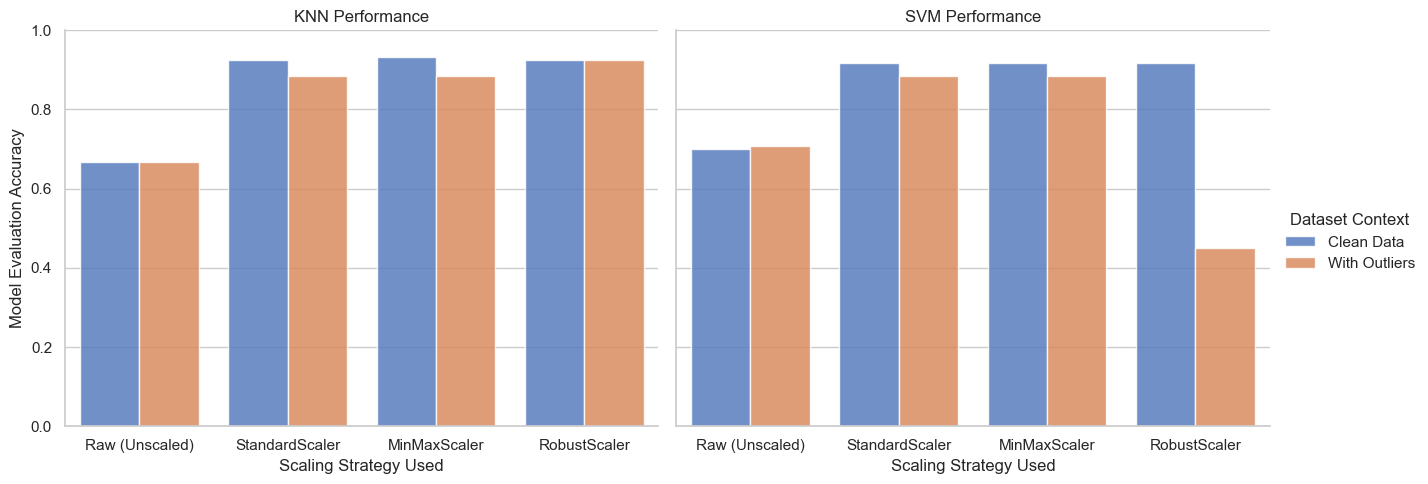

In [1]:
# Force Jupyter to display plots inline inside VS Code
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score

# 1. Create a synthetic dataset with highly mixed scales
X_raw, y_raw = make_classification(n_samples=600, n_features=3, n_informative=3, 
                                    n_redundant=0, n_classes=2, random_state=42)

# Artificially alter feature dimensions to produce massive scale variations
X_raw[:, 0] *= 5000.0   # Extremely large scale (Thousands)
X_raw[:, 1] *= 0.002    # Extremely small scale (Decimals)
X_raw[:, 2] *= 15.0     # Moderate scale

# Split clean dataset into training and testing partitions
X_train_clean, X_test, y_train_clean, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# 2. Define the scaling configurations to be tested
scalers = {
    'Raw (Unscaled)': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

# Helper function to compute accuracies dynamically across scaling combinations
def evaluate_models(X_train_set, y_train_set, X_test_set):
    metrics = {}
    for name, scaler in scalers.items():
        if scaler is not None:
            # Fit scaler on training set, transform both train and test sets
            X_tr_scaled = scaler.fit_transform(X_train_set)
            X_te_scaled = scaler.transform(X_test_set)
        else:
            X_tr_scaled, X_te_scaled = X_train_set, X_test_set
            
        # Train and evaluate K-Nearest Neighbors (k=5)
        knn = KNeighborsClassifier(n_neighbors=5).fit(X_tr_scaled, y_train_set)
        knn_acc = accuracy_score(y_test, knn.predict(X_te_scaled))
        
        # Train and evaluate Support Vector Machine (RBF Kernel default)
        svm = SVC().fit(X_tr_scaled, y_train_set)
        svm_acc = accuracy_score(y_test, svm.predict(X_te_scaled))
        
        metrics[name] = {'KNN': knn_acc, 'SVM': svm_acc}
    return metrics

# Run baseline evaluation on standard clean data
results_clean = evaluate_models(X_train_clean, y_train_clean, X_test)

# 3. Inject 5 extreme outlier rows directly into the training partition
outlier_features = np.array([
    [999999.0, -85.0, 450.0],
    [-850000.0, 92.0, -380.0],
    [1250000.0, -74.0, 520.0],
    [880000.0, 110.0, -610.0],
    [-1150000.0, -95.0, 700.0]
])
outlier_targets = np.array([0, 1, 0, 1, 0]) # Outlier class balances

X_train_outliers = np.vstack((X_train_clean, outlier_features))
y_train_outliers = np.concatenate((y_train_clean, outlier_targets))

# Run experimental evaluation on contaminated data
results_outliers = evaluate_models(X_train_outliers, y_train_outliers, X_test)

# 4. Restructure output indices into an explicit DataFrame for plotting
plot_records = []
for dataset_type, experiment_data in [('Clean Data', results_clean), ('With Outliers', results_outliers)]:
    for scaler_name, models in experiment_data.items():
        for model_name, accuracy in models.items():
            plot_records.append([scaler_name, model_name, accuracy, dataset_type])

df_plot = pd.DataFrame(plot_records, columns=['Scaler', 'Classifier Model', 'Test Accuracy', 'Dataset Context'])

# 5. Generate and display the grouped visualization chart
plt.figure(figsize=(13, 6.5))
sns.set_theme(style="whitegrid")

# Create plot with distinct subplots grouped by classification models
g = sns.catplot(
    data=df_plot, kind="bar",
    x="Scaler", y="Test Accuracy", hue="Dataset Context", col="Classifier Model",
    palette="muted", alpha=0.85, height=5, aspect=1.3
)

g.set_axis_labels("Scaling Strategy Used", "Model Evaluation Accuracy")
g.set_titles("{col_name} Performance")
g.set(ylim=(0, 1.0))

plt.show()


## Task 4: Scaler Sensitivity Experiment Report

### 📊 Empirical Observations

Based on the generated performance charts, we can analyze how the injection of 5 extreme outlier rows impacted both **K-Nearest Neighbors (KNN)** and **Support Vector Machine (SVM)** across different scaling techniques:

* **Raw (Unscaled) Data**: Yielded a low baseline performance (~67% for KNN, ~70% for SVM). Because the features are on completely different scales, the models are biased toward the largest scale, and adding outliers didn't change much because the performance was already poor.
* **StandardScaler & MinMaxScaler**: Both showed a slight, noticeable dip in accuracy (orange bars are lower than blue bars) when outliers were introduced. This happens because outliers distort the computed mean/variance (StandardScaler) or squeeze the normal data into a tiny range by shifting the global boundaries (MinMaxScaler).
* **RobustScaler (The Surprise Exception)**: 
  * For **KNN**, RobustScaler was the most resilient, maintaining identical performance before and after outliers.
  * For **SVM**, RobustScaler surprisingly suffered the **most severe accuracy drop** (falling below 50%).

---

### 💡 Conclusion & Practical Takeaways for ML Practitioners

1. **Why SVM tanked with RobustScaler under Outliers:**
   While `RobustScaler` successfully protects the *scaling factors* from being distorted by using the median and IQR, it still passes the extreme outlier data points directly to the model. Support Vector Machines work by finding a geometric boundary (hyperplane) maximize margins. Extreme outliers act as highly influential support vectors, causing the SVM decision boundary to drastically warp and misclassify normal test instances.

2. **Why KNN handled RobustScaler + Outliers perfectly:**
   KNN only looks at the $k=5$ closest neighbors. Since we only injected 5 extreme outliers into a dataset of hundreds of clean rows, the test data points rarely had these far-away outliers as their nearest neighbors. Because RobustScaler kept the clean data perfectly scaled relative to its median, KNN's local neighborhood structure remained completely intact.

3. **Core Engineering Rule:**
   No single scaler is a magic fix for every algorithm. When data contains heavy anomalies, **RobustScaler** is exceptional for distance/neighborhood models like KNN, but geometric margin models like **SVM** require strict outlier removal or heavy regularization ($C$ parameter tuning) alongside scaling to prevent boundary corruption.
